In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import torch

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from pathlib import Path
from plotting import plot_sagd_heatmap_row_with_prob, plot_breakpoint_and_speciation
from tqdm import tqdm

from plotting import plot_state_and_ctd_frame, extended_gray_coolwarm

In [3]:
ds = [2, 50, 256, 1024, 16384]

path = Path('../data/exp_01')

W_list = []
time_snaps_vector_list = []
ts_tuple_list = []
tsagd_tuple_list = []
std = 1.0
mu = None

for d_i in ds:
    ld = joblib.load(path / f"D{d_i}_N1000_T10/history.jbl")
    breakpoints = joblib.load(path / f"D{d_i}_N1000_T10/clusters.jbl")
    W_list.append(joblib.load(path / f"D{d_i}_N1000_T10/SAGD.jbl"))
    snaps = ld['params']['times_snapshots']
    t_s_i = ld['params']['ts_theoretical']
    mu = ld['params']['mu']
    time_snaps_vector_list.append(snaps)
    print({"Dim: {}, breakpoints: {}".format(d_i, breakpoints)})
    t_sagd_idx = breakpoints[0]
    t_sagd = snaps[t_sagd_idx]
    ts_tuple_list.append((t_s_i, int(np.argmin(np.abs(snaps - t_s_i)))))
    tsagd_tuple_list.append((t_sagd, t_sagd_idx))

{'Dim: 2, breakpoints: [np.int64(94), np.int64(95), np.int64(96), np.int64(97), np.int64(98), np.int64(99), np.int64(100), np.int64(101)]'}
{'Dim: 50, breakpoints: [np.int64(86), np.int64(87), np.int64(88), np.int64(90), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96)]'}
{'Dim: 256, breakpoints: [np.int64(80), np.int64(81), np.int64(87), np.int64(88), np.int64(89), np.int64(91), np.int64(92), np.int64(94), np.int64(96)]'}
{'Dim: 1024, breakpoints: [np.int64(75), np.int64(76), np.int64(88), np.int64(91), np.int64(92), np.int64(93), np.int64(94), np.int64(95), np.int64(96)]'}
{'Dim: 16384, breakpoints: [np.int64(67), np.int64(68), np.int64(88), np.int64(89), np.int64(91), np.int64(92), np.int64(94), np.int64(95), np.int64(96)]'}


/home/itolstoganov/miniforge3/envs/sagd-regimes/lib/python3.10/site-packages/ou_model.py:119: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(part, x0, -x0, epsrel=1e-4)[0]
/home/itolstoganov/miniforge3/envs/sagd-regimes/lib/python3.10/site-packages/ou_model.py:119: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(part, x0, -x0, epsrel=1e-4)[0]
/home/itolstoganov/miniforge3/envs/sagd-regimes/lib/python3.10/site-packages/ou_model.py:119: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral = integrate.quad(part, x0, -x0, epsrel=1e-4)[0]


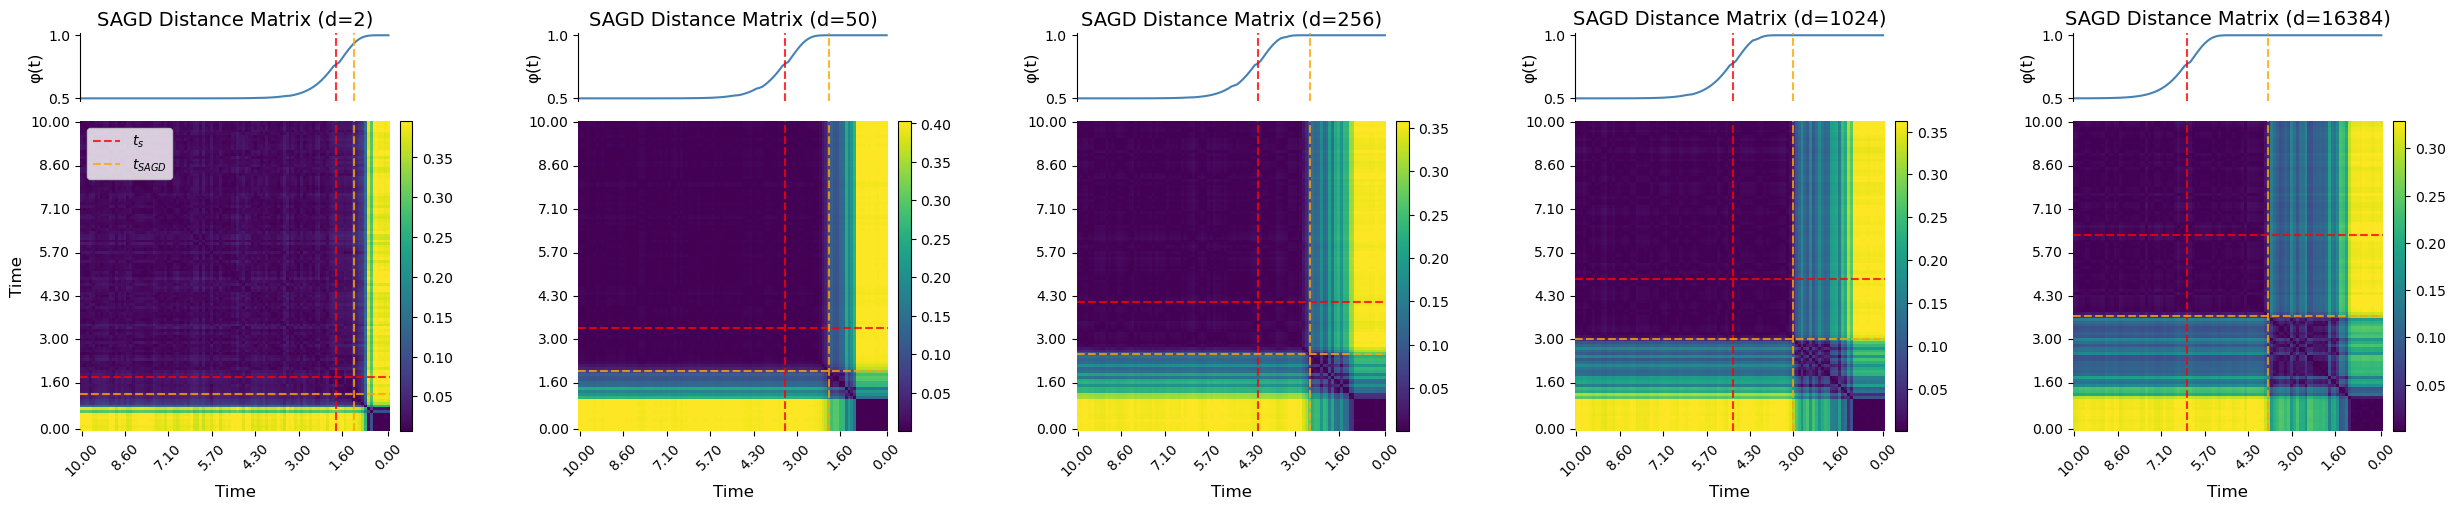

In [4]:
plot_sagd_heatmap_row_with_prob(
    W_list=W_list,
    d_list=ds,
    time_snaps_vector_list=time_snaps_vector_list,
    ts_tuple_list=ts_tuple_list,
    mu=mu,
    std=std,
    tsagd_tuple_list=tsagd_tuple_list,
    save_fig_path='../figures/sagd_heatmap_row_with_prob.png',
)

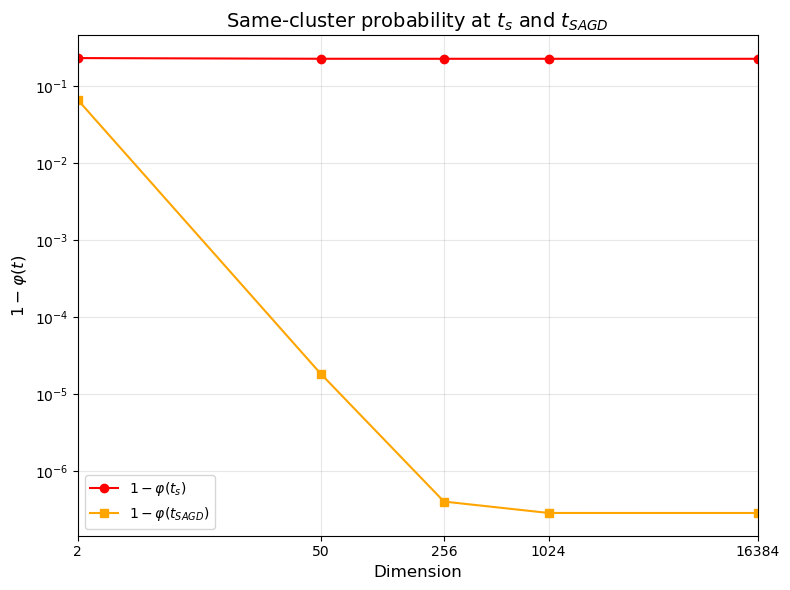

In [5]:
plot_breakpoint_and_speciation(
        d_list=ds,
        ts_tuple_list=ts_tuple_list,
        tsagd_tuple_list=tsagd_tuple_list,
        mu=mu,
        std=std,
        save_fig_path='../figures/speciation_and_sagd_times.png',
)

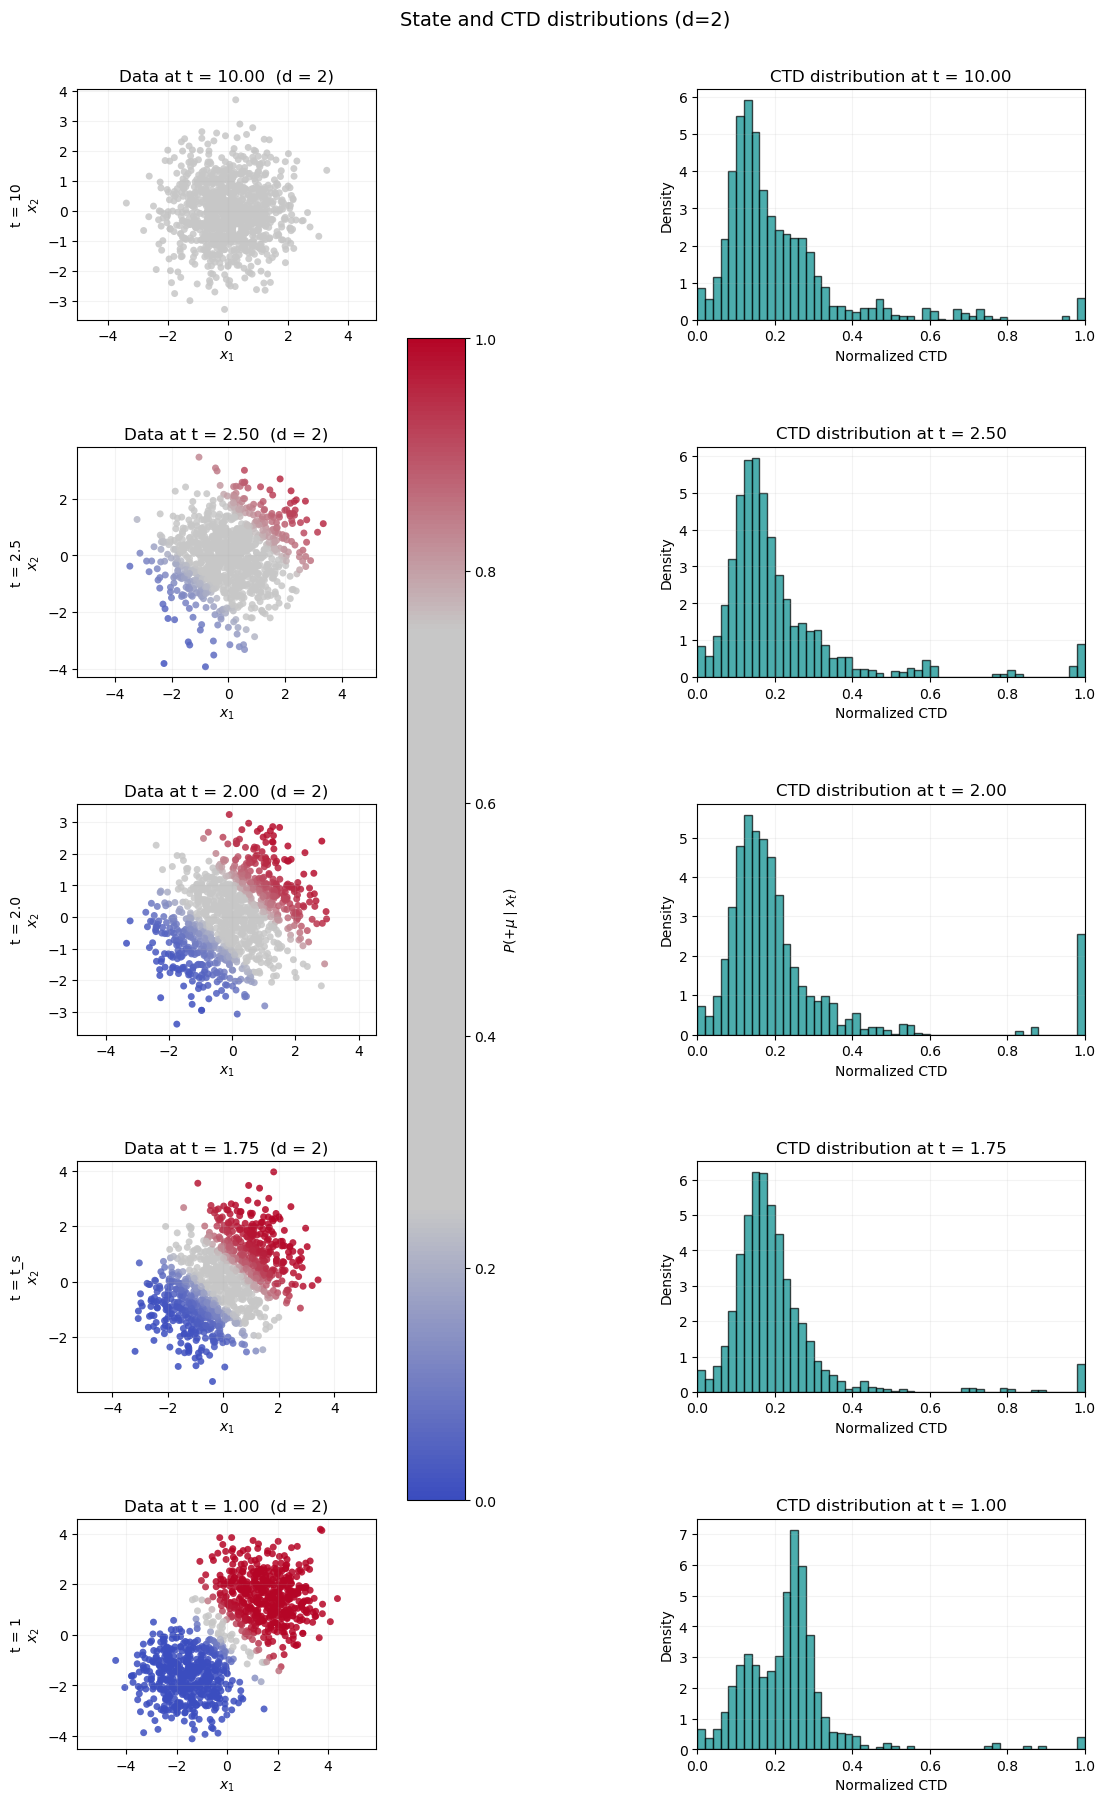

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from plotting import plot_state_and_ctd_frame, extended_gray_coolwarm

d_plot = 2
hist_load = joblib.load(path / f"D{d_plot}_N1000_T10/history.jbl")
ctds_load = joblib.load(path / f"D{d_plot}_N1000_T10/CTDs.jbl")

history = hist_load['history']
ctds_dict = ctds_load['CTDs']
t_s_d = hist_load['params']['ts_theoretical']
mu_d = hist_load['params']['mu']

time_snaps = list(history.keys())
ts_arr = np.array(time_snaps)
history_list = [history[t] for t in time_snaps]
norm_ctds_list = [ctds_dict[t]['norm_ctds'] for t in time_snaps]

target_times = [10.0, 2.5, 2.0, t_s_d, 1.0]
target_labels = ['t = 10', 't = 2.5', 't = 2.0', 't = t_s', 't = 1']
target_idx = [int(np.argmin(np.abs(ts_arr - tt))) for tt in target_times]

fig, axes = plt.subplots(len(target_idx), 2, figsize=(13, 4 * len(target_idx)))
fig.subplots_adjust(hspace=0.55, wspace=0.6, top=0.94)

for row, (idx, lbl) in enumerate(zip(target_idx, target_labels)):
    plot_state_and_ctd_frame(
        step_idx=idx,
        history_list=history_list,
        norm_ctds_list=norm_ctds_list,
        time_snaps=time_snaps,
        mu=mu_d,
        std=std,
        fig=fig,
        axes=axes[row],
        show=False,
    )
    axes[row, 0].set_ylabel(f"{lbl}\n{axes[row, 0].get_ylabel()}")

sm = ScalarMappable(cmap=extended_gray_coolwarm(), norm=Normalize(0.0, 1.0))
sm.set_array([])
fig.colorbar(sm, ax=axes[:, 0].ravel().tolist(), shrink=0.7, pad=0.08,
             label=r"$P(+\mu \mid x_t)$")
fig.suptitle(f"State and CTD distributions (d={d_plot})", fontsize=14)
plt.show()